How to define Egocentric Boundary Cell
- make Egocentric Boundary Ratemap
- compute Mean Resultant Length from EBR
- linear shift! MRL real needs to be 99th perc of shifted MRL
- compute MRL for two halves of the session:
    - pref. angle difference less than 45deg
    - pref. distance in halves vs. whole less than 50% difference

In [1]:
%load_ext autoreload
from behave_analysis.process.process import Process
from behave_analysis.analyze.filtering_data.filtering_functions import filter_video_dataframe

import os
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
"""Load data"""
from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip4_21mar
exp = JAL6_flip4_21mar

# load session
session = Process(exp).load_session()
base_path = os.path.join(session.base_path, session.processed_path)

# spikeys
spike_df = pl.read_csv(os.path.join(base_path, "good_spike_data.csv"))
video_df = pl.read_csv(os.path.join(base_path, "full_video_dataframe.csv"))

In [3]:
"""Filter relevant frames, keep only useful columns - reduce data size"""
# filter video_df and only keep important variables
video_df = filter_video_dataframe(video_df, condition = None, outofshelter=True, exclude_escape=True, exclude_homings=False, select_homings=False, excl_stationary = False)

video_df = video_df.select(["frames","hdir","mouse_x_position","mouse_y_position","barrier_present","barrier_flipped"])

# keep only relevant variables from spike_data
spike_df = spike_df.select(["spike_aligned_to_frame","spike_clusters"])

Make ratemaps

In [17]:
"""Extract variables for EBR calculation"""

neuron = 17
cluster_Id = np.unique(spike_df["spike_clusters"].to_numpy())
this_neuron_Id = cluster_Id[neuron]

# position
bin_x = video_df["mouse_x_position"].to_numpy()
bin_y = video_df["mouse_y_position"].to_numpy()
position = np.column_stack((bin_x, bin_y))

# head direction
head_direction = video_df["hdir"].to_numpy()

# spikes for this neuron - which frame di each spike occur on? use that to idx positions
this_neuron_spikes = np.array(spike_df["spike_aligned_to_frame"].filter((spike_df["spike_clusters"] == this_neuron_Id)).to_numpy())
frames = np.array(video_df['frames'].to_numpy())
spikes = [position[np.where(frames == int(spike))[0][0],:] for spike in this_neuron_spikes if len(np.where(frames == int(spike))[0]) > 0]

# boundaries
# Arena parameters
arena_center = np.array([512, 512])  # Center of the image
arena_radius = 460

# Generate boundary pixels
theta = np.linspace(0, 2 * np.pi, 1000)  # 1000 points around the circle
boundary_x = (arena_center[0] + arena_radius * np.cos(theta)).astype(int)
boundary_y = (arena_center[1] + arena_radius * np.sin(theta)).astype(int)

# Stack into a (K,2) array
boundaries = np.column_stack((boundary_x, boundary_y))

IndexError: index 0 is out of bounds for axis 0 with size 0

In [46]:
t = time.time()
smoothed_ebr, occupancy_map = compute_ebr(position, head_direction, spikes, boundaries, max_distance=125, dist_bin_size=2.5, angle_bin_size=3, smooth_sigma=5)
print(time.time() - t)

939.4573113918304


In [48]:
t = time.time()
smoothed_ebr_disc, occupancy_map_disc = compute_ebr_disc(position, head_direction, spikes, boundaries, max_distance=125, dist_bin_size=2.5, angle_bin_size=3, smooth_sigma=5)
print(time.time() - t)

1073.6388866901398


In [52]:
t = time.time()
smoothed_ebr_vect, occupancy_map_vect = compute_ebr_vect(position, head_direction, spikes, boundaries, max_distance=125, dist_bin_size=2.5, angle_bin_size=3, smooth_sigma=5)
print(time.time() - t)

IndexError: index 1000 is out of bounds for axis 0 with size 1000

: 

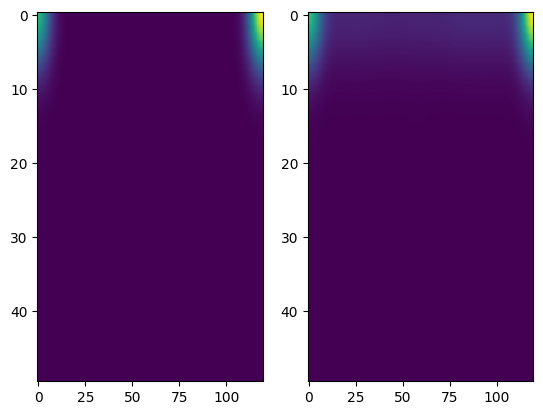

In [50]:
fig, axs = plt.subplots(1,2)
axs[0].imshow(smoothed_ebr, aspect = 'auto')
axs[1].imshow(smoothed_ebr_disc, aspect = 'auto')


In [45]:
import numpy as np
from scipy.ndimage import gaussian_filter

def compute_ebr(position, head_direction, spikes, boundaries, max_distance=125, dist_bin_size=2.5, angle_bin_size=3, smooth_sigma=5):
    """
    Compute the Egocentric Boundary Rate (EBR) map.

    Parameters:
    - position: (N,2) array of [x, y] positions over time
    - head_direction: (N,) array of angles in degrees (0° = forward)
    - spikes: (M,2) array of [x, y] spike locations
    - boundaries: (K,2) array of [x, y] boundary locations
    - max_distance: Maximum distance to consider boundaries (default 125 cm)
    - dist_bin_size: Bin size for distance (default 2.5 cm)
    - angle_bin_size: Bin size for angles (default 3°)
    - smooth_sigma: Smoothing factor for Gaussian filter (default 5 bins)

    Returns:
    - EBR map (2D array) and occupancy map (2D array)
    """

    # Define bin edges
    distance_bins = np.arange(0, max_distance + dist_bin_size, dist_bin_size)  # Distance bins
    angle_bins = np.arange(0, 360 + angle_bin_size, angle_bin_size)  # Angular bins

    # Initialize maps
    occupancy_map = np.zeros((len(distance_bins)-1, len(angle_bins)-1))
    spike_map = np.zeros_like(occupancy_map)

    # Loop over each time frame to compute occupancy
    for i in range(len(position)):
        px, py = position[i]
        hd = head_direction[i]  # Head direction in degrees
        
        # Compute egocentric distances & angles to all boundaries
        dx, dy = boundaries[:, 0] - px, boundaries[:, 1] - py
        distances = np.hypot(dx, dy)  # Euclidean distance
        angles = (np.degrees(np.arctan2(dy, dx)) - hd) % 360  # Egocentric angles
        
        # Mask out distances beyond max range
        valid = distances <= max_distance
        distances, angles = distances[valid], angles[valid]

        # Bin distances and angles
        dist_idx = np.digitize(distances, distance_bins) - 1
        angle_idx = np.digitize(angles, angle_bins) - 1
        
        # Accumulate occupancy time
        for d, a in zip(dist_idx, angle_idx):
            occupancy_map[d, a] += 1

    # Loop over spikes to compute spike counts
    for sx, sy in spikes:
        # Find closest time point to the spike
        idx = np.argmin(np.hypot(position[:, 0] - sx, position[:, 1] - sy))
        px, py = position[idx]
        hd = head_direction[idx]

        # Compute spike egocentric location
        dx, dy = sx - px, sy - py
        spike_dist = np.hypot(dx, dy)
        spike_angle = (np.degrees(np.arctan2(dy, dx)) - hd) % 360
        
        # Ignore spikes beyond max range
        if spike_dist > max_distance:
            continue

        # Bin spike distance and angle
        d_idx = np.digitize([spike_dist], distance_bins) - 1
        a_idx = np.digitize([spike_angle], angle_bins) - 1
        
        spike_map[d_idx, a_idx] += 1

    # Compute EBR
    ebr_map = np.divide(spike_map, occupancy_map, where=occupancy_map > 0)  # Avoid division by zero

    # Smooth EBR with Gaussian kernel
    smoothed_ebr = gaussian_filter(ebr_map, sigma=smooth_sigma)

    return smoothed_ebr, occupancy_map

In [47]:
import numpy as np
from scipy.ndimage import gaussian_filter

def compute_ebr_disc(position, head_direction, spikes, boundaries, max_distance=125, dist_bin_size=2.5, angle_bin_size=3, smooth_sigma=5):
    """
    Compute the Egocentric Boundary Rate (EBR) map with binned positions and head directions.
    
    Parameters:
    - position: (N,2) array of [x, y] positions over time
    - head_direction: (N,) array of angles in degrees (0° = forward)
    - spikes: (M,2) array of [x, y] spike locations
    - boundaries: (K,2) array of [x, y] boundary locations
    - max_distance: Maximum distance to consider boundaries (default 125 cm)
    - dist_bin_size: Bin size for distance (default 2.5 cm)
    - angle_bin_size: Bin size for angles (default 3°)
    - smooth_sigma: Smoothing factor for Gaussian filter (default 5 bins)

    Returns:
    - EBR map (2D array) and occupancy map (2D array)
    """
    # Define bin edges
    distance_bins = np.arange(0, max_distance + dist_bin_size, dist_bin_size)  # Distance bins
    angle_bins = np.arange(0, 360 + angle_bin_size, angle_bin_size)  # Angular bins

    # Initialize maps
    occupancy_map = np.zeros((len(distance_bins)-1, len(angle_bins)-1))
    spike_map = np.zeros_like(occupancy_map)

    # Bin positions and head directions
    dist_idx = np.digitize(np.linalg.norm(position - position.mean(axis=0), axis=1), distance_bins) - 1
    angle_idx = np.digitize(head_direction, angle_bins) - 1

    # Find unique (dist_idx, angle_idx) combinations
    unique_combinations = np.unique(np.column_stack((dist_idx, angle_idx)), axis=0)

    # Loop over unique position and head direction combinations
    for d, a in unique_combinations:
        # For this combination, find positions and head directions that fall into the bin
        mask = (dist_idx == d) & (angle_idx == a)
        positions_in_bin = position[mask]
        directions_in_bin = head_direction[mask]

        # Loop over these positions and compute boundary distances
        for px, py, hd in zip(positions_in_bin[:, 0], positions_in_bin[:, 1], directions_in_bin):
            # Compute egocentric distances & angles to all boundaries
            dx, dy = boundaries[:, 0] - px, boundaries[:, 1] - py
            distances = np.hypot(dx, dy)  # Euclidean distance
            angles = (np.degrees(np.arctan2(dy, dx)) - hd) % 360  # Egocentric angles
            
            # Mask out distances beyond max range
            valid = distances <= max_distance
            distances, angles = distances[valid], angles[valid]

            # Bin distances and angles
            dist_idx_bin = np.digitize(distances, distance_bins) - 1
            angle_idx_bin = np.digitize(angles, angle_bins) - 1
            
            # Accumulate occupancy time
            for d_bin, a_bin in zip(dist_idx_bin, angle_idx_bin):
                occupancy_map[d_bin, a_bin] += 1
        
        # Loop over spikes to compute spike counts for this unique combination
        for sx, sy in spikes:
            # Find closest time point to the spike
            idx = np.argmin(np.hypot(positions_in_bin[:, 0] - sx, positions_in_bin[:, 1] - sy))
            px, py = positions_in_bin[idx]
            hd = directions_in_bin[idx]

            # Compute spike egocentric location
            dx, dy = sx - px, sy - py
            spike_dist = np.hypot(dx, dy)
            spike_angle = (np.degrees(np.arctan2(dy, dx)) - hd) % 360
            
            # Ignore spikes beyond max range
            if spike_dist > max_distance:
                continue

            # Bin spike distance and angle
            d_idx = np.digitize([spike_dist], distance_bins) - 1
            a_idx = np.digitize([spike_angle], angle_bins) - 1
            
            spike_map[d_idx, a_idx] += 1

    # Compute EBR
    ebr_map = np.divide(spike_map, occupancy_map, where=occupancy_map > 0)  # Avoid division by zero

    # Smooth EBR with Gaussian kernel
    smoothed_ebr = gaussian_filter(ebr_map, sigma=smooth_sigma)

    return smoothed_ebr, occupancy_map


In [51]:
import numpy as np
from scipy.ndimage import gaussian_filter
from scipy.spatial import cKDTree

def compute_ebr_vect(position, head_direction, spikes, boundaries, max_distance=125, dist_bin_size=2.5, angle_bin_size=3, smooth_sigma=5):
    """
    Compute Egocentric Boundary Rate (EBR) map using optimized vectorized operations and KD-tree for speedup.
    """
    # Define bin edges
    distance_bins = np.arange(0, max_distance + dist_bin_size, dist_bin_size)  # Distance bins
    angle_bins = np.arange(0, 360 + angle_bin_size, angle_bin_size)  # Angular bins

    # Initialize maps
    occupancy_map = np.zeros((len(distance_bins)-1, len(angle_bins)-1))
    spike_map = np.zeros_like(occupancy_map)

    # Create KDTree for fast boundary lookup
    boundary_tree = cKDTree(boundaries)

    # Bin positions and head directions
    pos_bins_x = np.floor(position[:, 0] / dist_bin_size).astype(int)
    pos_bins_y = np.floor(position[:, 1] / dist_bin_size).astype(int)
    angle_bins_idx = np.floor(head_direction / angle_bin_size).astype(int) % (360 // angle_bin_size)

    # Create a unique index for each (position_bin, angle_bin) combination
    unique_bins, bin_indices = np.unique(np.column_stack((pos_bins_x, pos_bins_y, angle_bins_idx)), axis=0, return_inverse=True)

    # Precompute boundary distances for unique bins
    bin_positions = unique_bins[:, :2] * dist_bin_size  # Convert bin indices back to spatial coordinates
    distances, boundary_indices = boundary_tree.query(bin_positions, distance_upper_bound=max_distance)

    # Compute egocentric angles
    dx, dy = boundaries[boundary_indices][:, 0] - bin_positions[:, 0], boundaries[boundary_indices][:, 1] - bin_positions[:, 1]
    angles = (np.degrees(np.arctan2(dy, dx)) - unique_bins[:, 2] * angle_bin_size) % 360

    # Bin distances and angles
    dist_idx = np.digitize(distances, distance_bins) - 1
    angle_idx = np.digitize(angles, angle_bins) - 1

    # Accumulate occupancy time
    np.add.at(occupancy_map, (dist_idx, angle_idx), 1)

    # Bin spike locations
    spike_bins_x = np.floor(spikes[:, 0] / dist_bin_size).astype(int)
    spike_bins_y = np.floor(spikes[:, 1] / dist_bin_size).astype(int)

    # Find the nearest position bin for each spike
    spike_bin_indices = np.searchsorted(unique_bins[:, :2], np.column_stack((spike_bins_x, spike_bins_y)), side='left')

    # Use those bins' head directions
    spike_head_directions = unique_bins[spike_bin_indices, 2] * angle_bin_size

    # Compute spike egocentric locations
    dx_spike = spikes[:, 0] - bin_positions[spike_bin_indices, 0]
    dy_spike = spikes[:, 1] - bin_positions[spike_bin_indices, 1]
    spike_distances = np.hypot(dx_spike, dy_spike)
    spike_angles = (np.degrees(np.arctan2(dy_spike, dx_spike)) - spike_head_directions) % 360

    # Ignore spikes beyond max range
    valid_spikes = spike_distances <= max_distance
    spike_distances, spike_angles = spike_distances[valid_spikes], spike_angles[valid_spikes]

    # Bin spikes
    d_idx = np.digitize(spike_distances, distance_bins) - 1
    a_idx = np.digitize(spike_angles, angle_bins) - 1

    # Accumulate spike counts
    np.add.at(spike_map, (d_idx, a_idx), 1)

    # Compute EBR
    ebr_map = np.divide(spike_map, occupancy_map, where=occupancy_map > 0)

    # Smooth EBR with Gaussian kernel
    smoothed_ebr = gaussian_filter(ebr_map, sigma=smooth_sigma)

    return smoothed_ebr, occupancy_map

Compute MRL